# Imports

In [18]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist
import itertools
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import bernoulli
import warnings
from GP import *
from plotter import *
from scipy.special import softmax
from scipy.spatial.distance import cdist
import gpytorch
import gymnasium as gym
from gymnasium.envs.registration import register

# 2AFC

## Simulations

  0%|          | 0/1 [00:00<?, ?it/s]

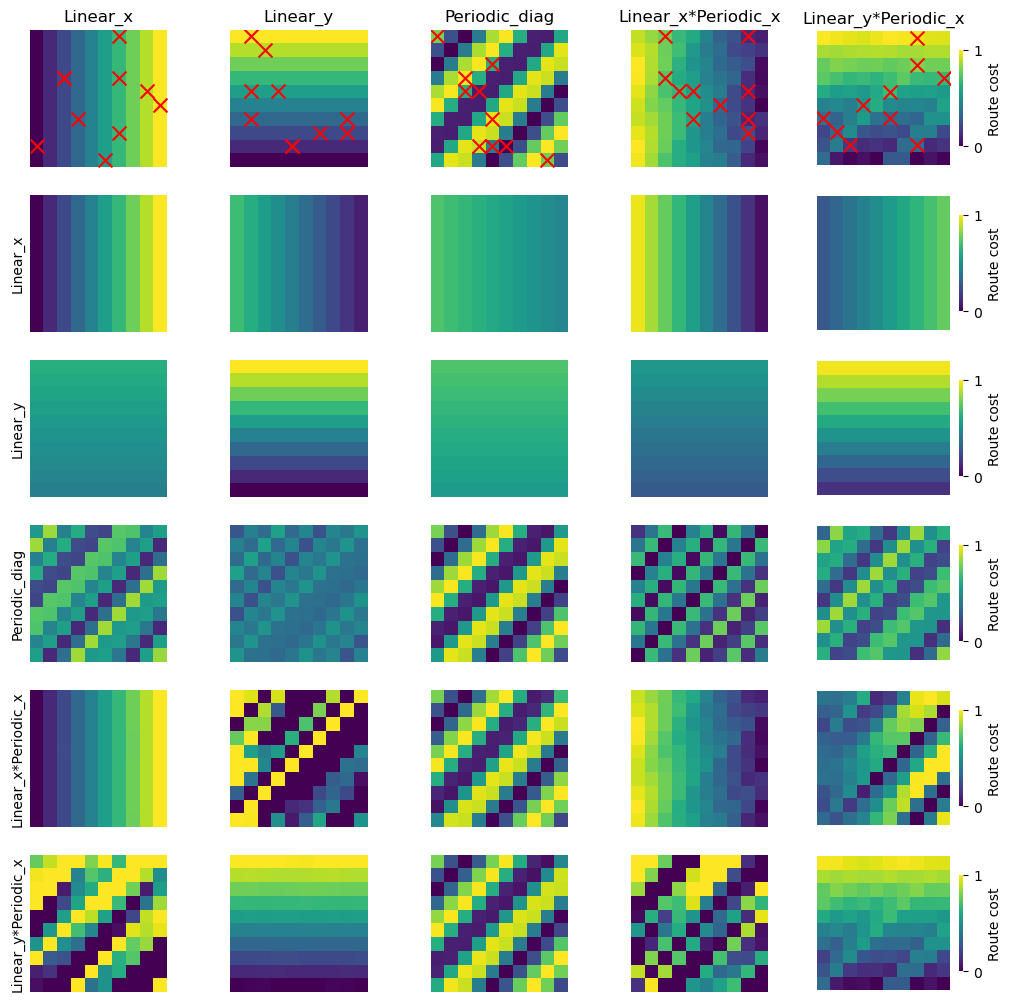

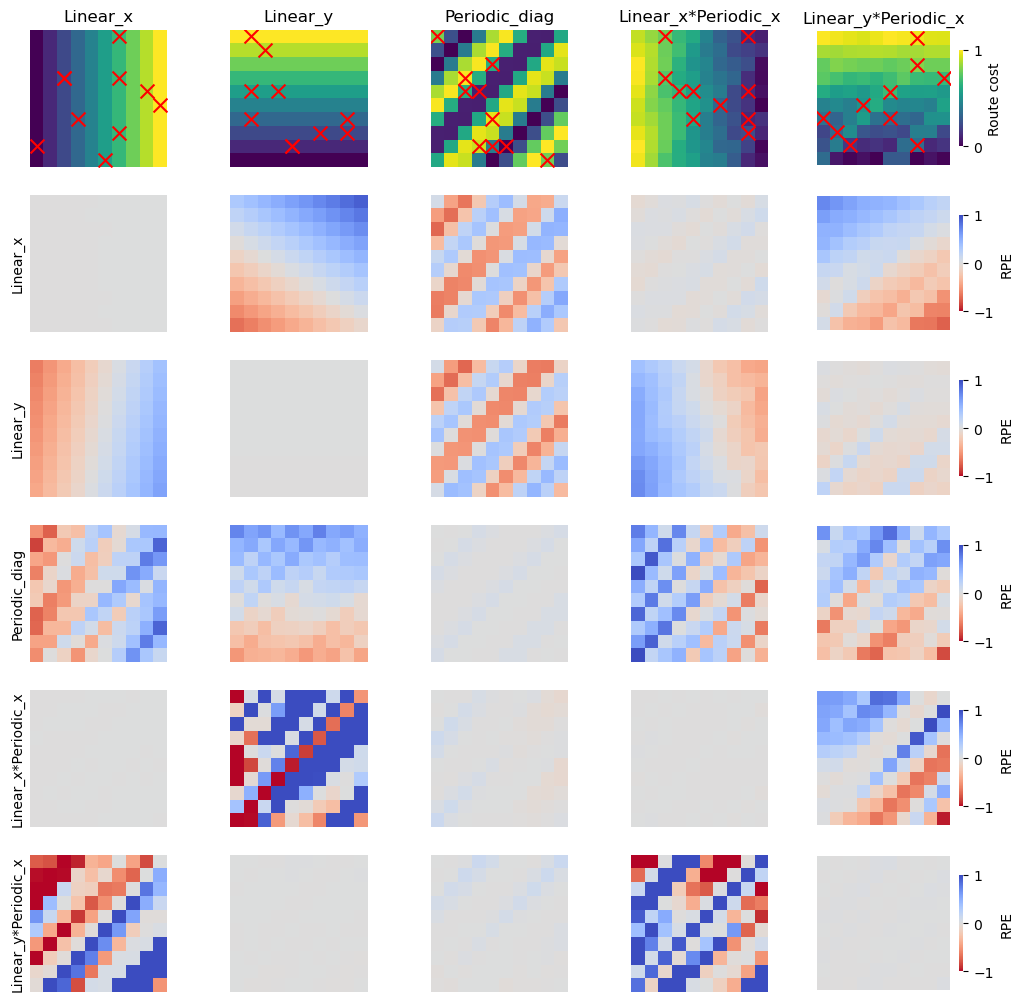

In [2]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

### zero in on interesting combos

## inititialise the GP
N = 10
c = [1]
scale = [1]
theta = [0]
sigma_f = [1]
length_scale = [N/2.5]
# length_scale = np.linspace(1,10,5, dtype = int)
period = [4]
# period = np.linspace(1,10,10)
periodic_length_scale = [4]
# periodic_length_scale = [N/2.5]
# periodic_length_scale = np.linspace(1,10,10)
# periodic_theta = [0]
periodic_theta = [np.pi/4]
# GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']

## init dict to store data
gp_dict = {
    'gen_kernel': [],
    'inf_kernel': [],
    'n_obs': [],
    'trial': [],
    'k_mll': [],
    'x_1': [],
    'x_2': [],
    'reward_1': [],
    'reward_2': [],
    'CP_1': [],
    'CP_2': [],
    'p(correct)': []
}
for param in param_names:
    gp_dict[param] = []

## loop through parameter initialisations
for pci in tqdm(range(len(param_combos))):
    params = param_combos[pci]

    ## define koi
    gp = GP_world(N, params)
    koi = [
        
        ## base kernels
        # gp.K_lin,
        gp.K_lin_x,
        gp.K_lin_y,
        # gp.K_rbf,
        # gp.K_rbf_x,
        # gp.K_rbf_y,
        gp.K_periodic_x,
        # gp.K_periodic_y,


        ## combos
        # gp.K_lin*gp.K_periodic_x,
        # gp.K_lin*gp.K_periodic_y,
        gp.K_lin_x*gp.K_periodic_x,
        gp.K_lin_y*gp.K_periodic_x,
        # gp.K_rbf_x*gp.K_periodic_x,
        # gp.K_rbf_y*gp.K_periodic_x,
        # gp.K_periodic_x*gp.K_periodic_y
    ]

    kernel_names = [
        ## base kernels
        # 'Linear',
        'Linear_x',
        'Linear_y',
        # 'RBF',
        # 'RBF_x',
        # 'RBF_y',
        # 'Periodic_x',
        # 'Periodic_y',
        'Periodic_diag',

        ## combos
        # 'Linear*Periodic_x',
        # 'Linear*Periodic_y',
        'Linear_x*Periodic_x',
        'Linear_y*Periodic_x',
        # 'RBF_x*Periodic_diag',
        # 'RBF_y*Periodic_diag',
        # 'Periodic_x*Periodic_y'
    ]


    ## init plots 
    n_k = len(koi)
    n_trials = 500
    if (pci == len(param_combos)-1):
        fig, axs = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))
        fig2, axs2 = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))



    ## loop through combos
    for kg, k_gen in enumerate(koi):
        k_gen_name = kernel_names[kg]
        gp.k_check(k_gen)

        ## loop through trials
        for t in range(n_trials):
        
            ## sample from combo kernel
            samples = gp.sample(k_gen)

            ## generate observations
            n_obs = 10
            all_obs = gp.gen_obs(samples, n_obs)
            
            ## for each trial, select two random points to choose between
            preds = gp.gen_preds(samples).squeeze()


            ## plot
            if (t == n_trials-1) & (pci == len(param_combos)-1):
                plot_r(samples, axs[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_r(samples, axs2[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_obs(all_obs, axs[0,kg], text=False)
                plot_obs(all_obs, axs2[0,kg], text=False)
            
            ## loop through inference kernels
            for ki, k_inf in enumerate(koi):
                k_inf_name = kernel_names[ki]

                ## incrementally increase the number of observations
                for o in range(n_obs):
                    obs = all_obs[:o+1]

                    ## calculate posterior of the points to compare, given the observations made so far
                    post_mean, post_cov = gp.post_pred(k_inf, obs, preds[:,0].astype(int))
                    # temp = 0.1
                    # choice_prob = softmax(post_mean/temp)
                    # choice_prob = gp.sigmoid(diff, tau)
                    choice_prob = [scipy.stats.norm.cdf(post_mean[0]-post_mean[1], 0, np.sum(np.diag(post_cov)))]
                    choice_prob.append(1-choice_prob[0])


                    ## compute log marginal likelihood under this kernel
                    ll = gp.likelihood(k_inf, obs)

                    ## save data
                    gp_dict['gen_kernel'].append(k_gen_name)
                    gp_dict['inf_kernel'].append(k_inf_name)
                    gp_dict['trial'].append(t)
                    gp_dict['k_mll'].append(ll)
                    gp_dict['n_obs'].append(o+1)
                    ## should also save the info about the observations somewhere
                    gp_dict['x_1'].append(preds[0,0])
                    gp_dict['x_2'].append(preds[1,0])
                    gp_dict['reward_1'].append(preds[0,-1])
                    gp_dict['reward_2'].append(preds[1,-1])
                    gp_dict['CP_1'].append(choice_prob[0])
                    gp_dict['CP_2'].append(choice_prob[1])
                    gp_dict['p(correct)'].append(choice_prob[np.argmax(preds[:,-1])])

                    ## save params
                    for param in param_names:
                        gp_dict[param].append(params[param_names.index(param)])
                
                ## plot the full posterior distribution once all observations have been made
                full_post_mean, _ = gp.post_pred(k_inf, obs)
                if (t == n_trials-1) & (pci == len(param_combos)-1):
                    plot_r(full_post_mean.reshape(N,N), axs[ki+1,kg], cbar = kg==(len(koi)-1))
                    RPE = samples-full_post_mean.reshape(N,N)
                    plot_RPE(RPE, axs2[ki+1,kg], cbar = (kg==(len(koi)-1)))
            

        ## loop through rows and add y-axis to the leftmost column
        if (t == n_trials-1) & (pci == len(param_combos)-1):
            for i in range(n_k):
                axs[i+1,0].set_ylabel(kernel_names[i])
                axs2[i+1,0].set_ylabel(kernel_names[i])

## convert ll_dict to df
df_gp = pd.DataFrame(gp_dict)

## Plots

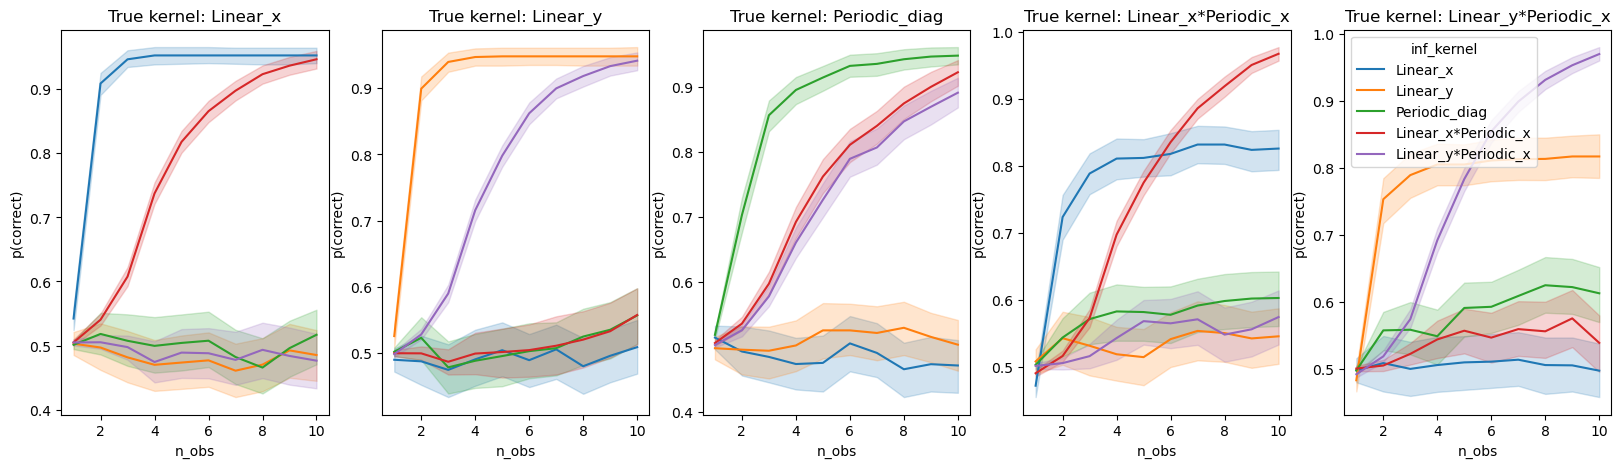

In [6]:
## accuracy

# param_of_interest = scale.copy()
# param_of_interest = length_scale.copy()
# param_of_interest = period.copy()
param_of_interest = periodic_length_scale.copy()
for p in periodic_length_scale:
    data_tmp = df_gp.loc[df_gp['periodic_length_scale']==p]
    fig, axs = plt.subplots(1, n_k, figsize=(4*n_k, 5))
    for gki, gen_k in enumerate(data_tmp['gen_kernel'].unique()):
        sns.lineplot(data = data_tmp.loc[data_tmp['gen_kernel']==gen_k], x = 'n_obs', y = 'p(correct)', hue = 'inf_kernel', ax = axs[gki], legend = gki==n_k-1)
        axs[gki].set_title('True kernel: '+gen_k)
    # plt.suptitle((p))


## MLL

fig, axs = plt.subplots(1,n_k, figsize=(20,5))
for i in range(n_k):
    sns.lineplot(data = df_gp.loc[df_gp['gen_kernel'] == kernel_names[i]], x = 'n_obs', y = 'k_mll', hue = 'inf_kernel', ax = axs[i], legend=i==0, )
    axs[i].set_title('True kernel: '+kernel_names[i])
    axs[i].set_xlabel('N obs')
    axs[i].set_ylabel('')
    # axs[i].set_ylim(-100,25)
axs[0].set_ylabel('log marginal likelihood')
# axs[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Trajectories

## Optimal simulations

  0%|          | 0/100 [00:00<?, ?it/s]

/var/folders/6f/wv4903p948xgctshsywsz13r0000gq/T/ipykernel_25672/3204608929.py:207: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_gp = pd.concat([df_gp, df_tmp], ignore_index = True)


,simple_cost,simple_cost_x,simple_cost_y,optimal_cost,optimality,optimality_x,optimality_y
count,800.000000,400.000000,400.000000,800.000000,800.000000,400.000000,400.000000
mean,4.600711,6.385326,6.084950,3.660488,0.807913,0.665463,0.689762
std,1.684696,2.123403,2.018663,1.509766,0.206622,0.238189,0.225636
min,0.234937,0.234937,0.331968,0.109589,0.140130,0.113459,0.138307
25%,3.462279,4.942959,4.865518,2.738957,0.703428,0.472332,0.507149
50%,4.539056,6.304511,6.064758,3.580498,0.871222,0.703862,0.744569
75%,5.685091,7.819683,7.353045,4.606223,0.985776,0.866935,0.871094
max,11.321998,11.710171,11.366295,8.765474,1.000000,1.000000,1.000000


,gen_kernel,trial,n_simple,n_simple_x,n_simple_y,n_optimal,simple_cost,simple_cost_x,simple_cost_y,o_traj,...,optimality_y,metric,inf_under_RBF,RPE_under_RBF,inf_under_RBF_x,RPE_under_RBF_x,inf_under_RBF_y,RPE_under_RBF_y,inf_under_Periodic,RPE_under_Periodic
0,RBF,0,14,14,14,16,6.215691,6.215691,7.489087,"[(8, 7), (7, 7), (6, 7), (5, 7), (5, 8), (4, 8...",...,0.800173,manhattan,5.992562,0.0,9.300306,-3.307744,6.895958,-0.903395,9.209963,-3.217401
1,RBF,0,8,NaN,NaN,9,5.004984,NaN,NaN,"[(8, 7), (7, 6), (6, 5), (6, 4), (5, 3), (4, 2...",...,NaN,chebyshev,4.994551,0.0,5.397435,-0.402883,5.190069,-0.195518,6.427624,-1.433073
2,RBF_x,0,14,14,14,14,2.767130,2.767130,6.500942,"[(8, 7), (8, 6), (8, 5), (7, 5), (6, 5), (5, 5...",...,0.228665,manhattan,2.970135,-1.483596,1.486539,0.0,5.434139,-3.947599,2.567751,-1.081212
3,RBF_x,0,8,NaN,NaN,8,2.202882,NaN,NaN,"[(8, 7), (7, 6), (6, 5), (5, 5), (4, 4), (3, 3...",...,NaN,chebyshev,3.202882,-1.716343,1.486539,0.0,4.202882,-2.716343,2.080517,-0.593978
4,RBF_y,0,14,14,14,14,4.864819,7.310413,4.864819,"[(8, 7), (7, 7), (6, 7), (6, 6), (6, 5), (6, 4...",...,0.712712,manhattan,8.023674,-4.556457,6.495215,-3.027998,3.467217,0.0,5.584595,-2.117379
5,RBF_y,0,8,NaN,NaN,10,3.467217,NaN,NaN,"[(8, 7), (7, 6), (6, 5), (6, 4), (6, 3), (5, 2...",...,NaN,chebyshev,3.467217,-0.0,3.467217,-0.0,3.467217,0.0,3.933084,-0.465868
6,Periodic,0,14,14,14,14,7.107561,7.452434,7.107561,"[(8, 7), (8, 6), (8, 5), (7, 5), (6, 5), (5, 5...",...,0.865803,manhattan,8.900287,-2.74654,6.925564,-0.771817,7.48961,-1.335863,6.153746,0.0
7,Periodic,0,8,NaN,NaN,10,3.944972,NaN,NaN,"[(8, 7), (8, 6), (8, 5), (7, 4), (6, 3), (5, 2...",...,NaN,chebyshev,4.727616,-0.797771,4.154693,-0.224848,4.944901,-1.015056,3.929845,0.0
8,RBF,1,13,13,13,13,3.453871,6.181490,3.453871,"[(8, 7), (7, 7), (7, 6), (7, 5), (7, 4), (6, 4...",...,0.848634,manhattan,2.931073,0.0,4.916364,-1.985291,4.793387,-1.862314,4.626983,-1.69591
9,RBF,1,7,NaN,NaN,8,2.265906,NaN,NaN,"[(8, 7), (7, 6), (7, 5), (6, 4), (5, 3), (4, 2...",...,NaN,chebyshev,1.970967,0.0,3.172012,-1.201045,2.265906,-0.294939,2.265906,-0.294939


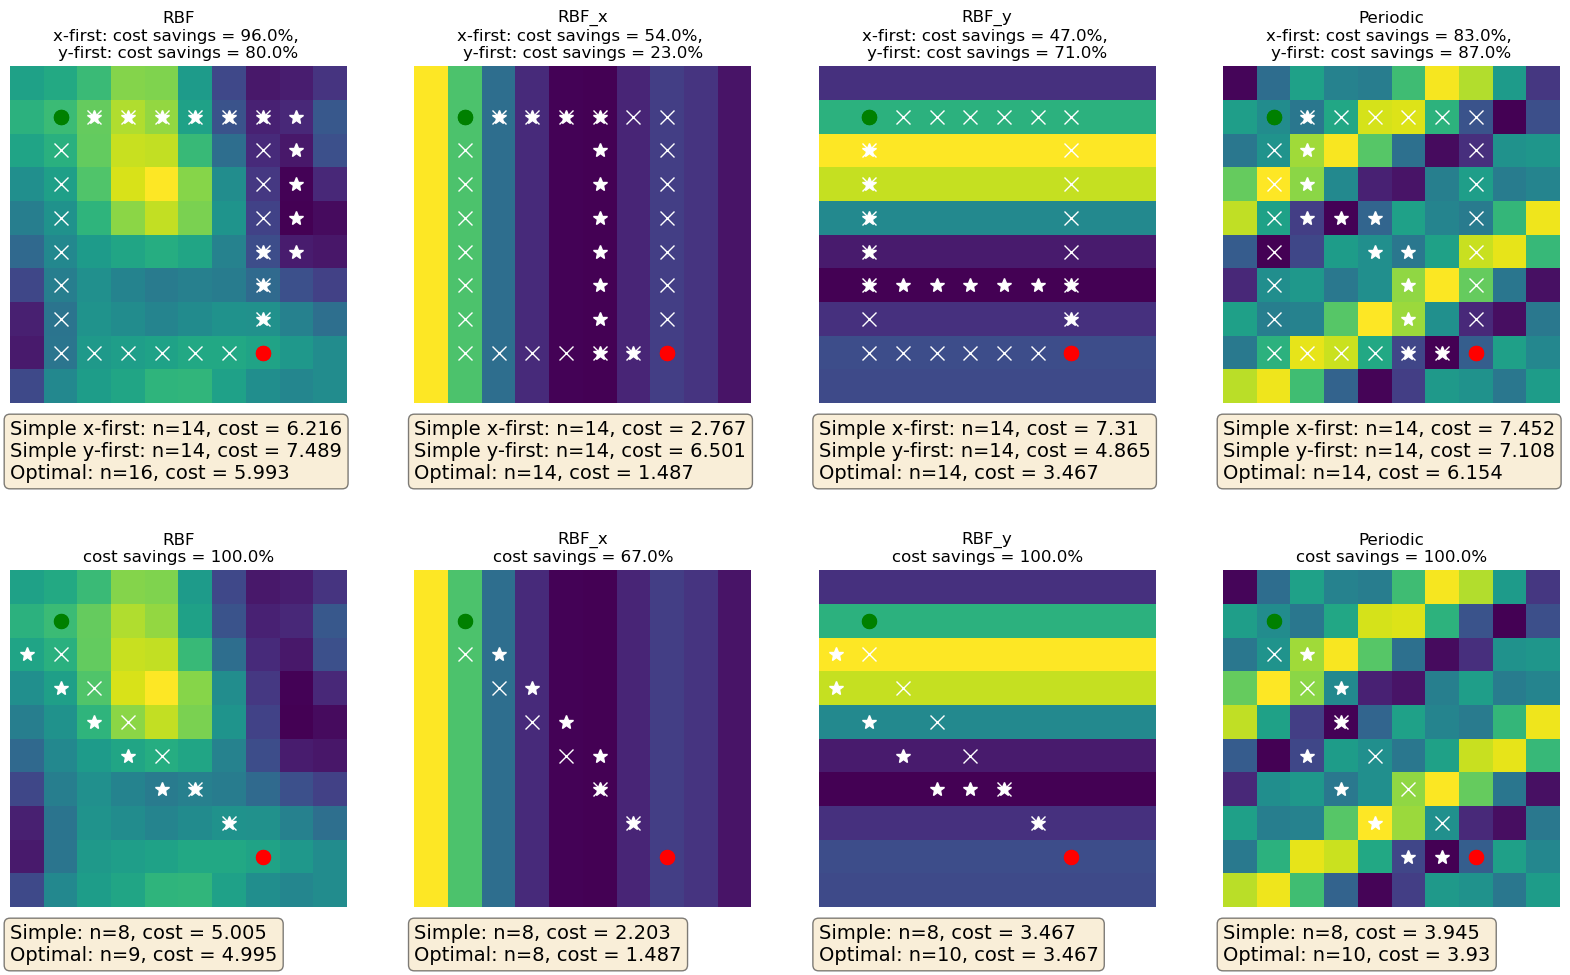

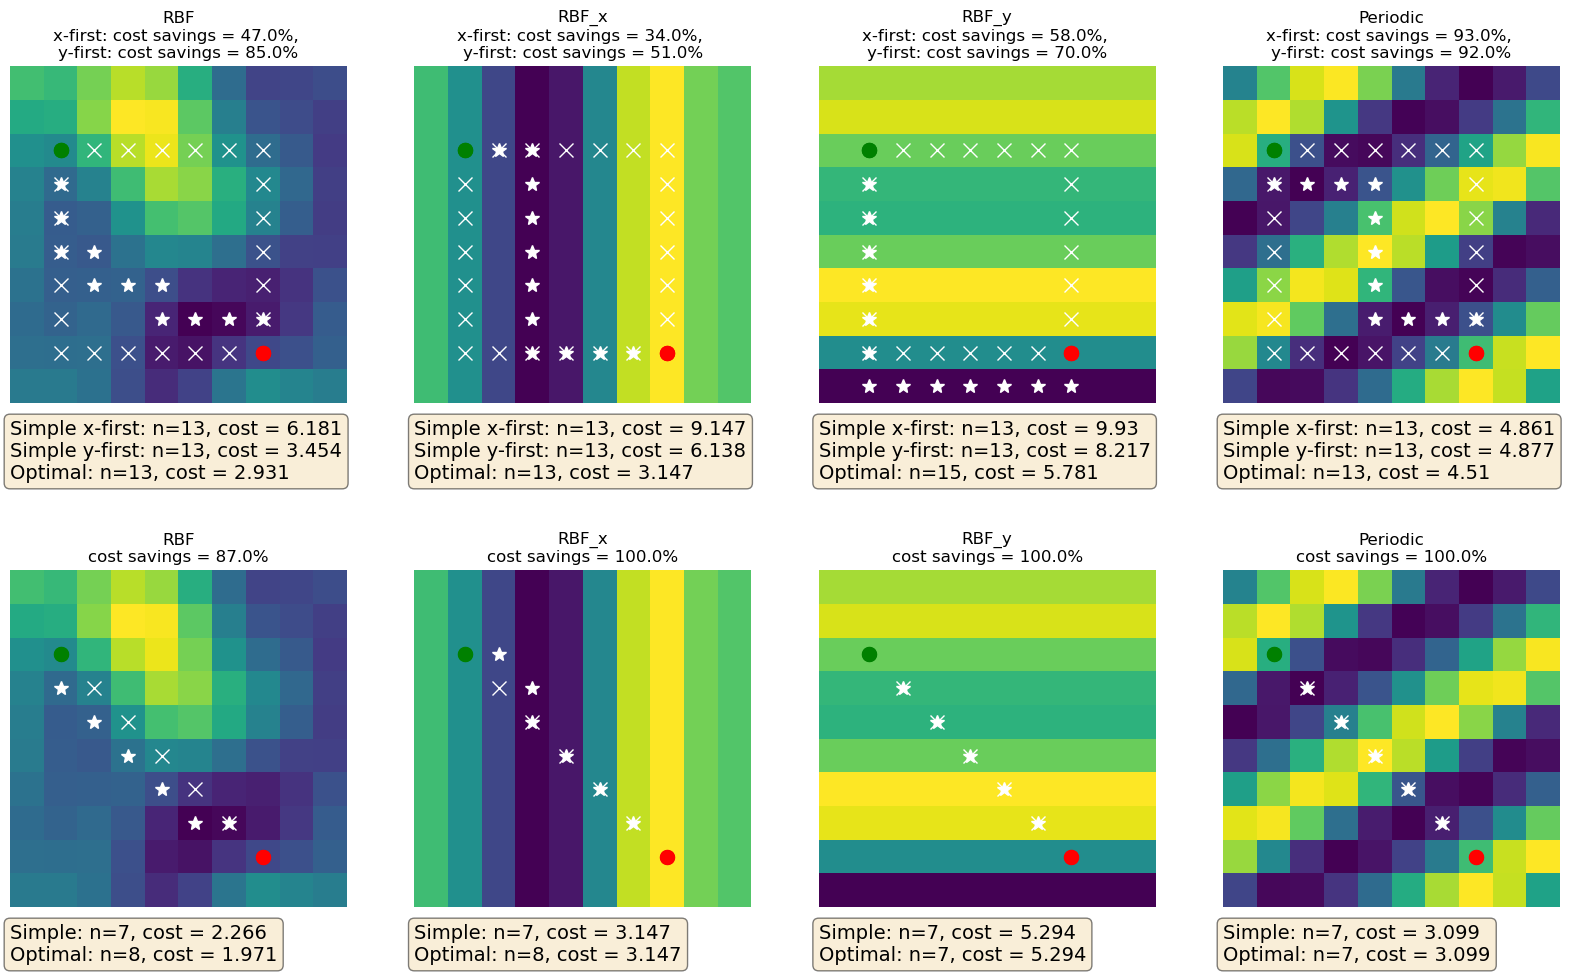

In [23]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

# ## inititialise the GP
N = 10
c = [1]
scale = [1]
theta = [0]
# theta = [np.pi/3]
sigma_f = [1]
length_scale = [N/5]
# length_scale = np.linspace(1,5,5, dtype = int)
period = [N/5]
# period = np.linspace(1,10,10)
# periodic_length_scale = [4]
periodic_length_scale = [N/2]
# periodic_length_scale = np.linspace(1,10,10)
periodic_theta = [0]
periodic_theta = [np.pi/3]
# GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']

## loop through parameter initialisations
for pci in range(len(param_combos)):
    params = param_combos[pci]

    ## GP init
    metric = 'chebyshev'
    metric = 'manhattan'
    metrics = [
        'manhattan',
        'chebyshev'
        ]
    n_metrics = len(metrics)
    gp = GP_world(N, params)
    koi = [
        
        ## base kernels
        # gp.K_lin,
        # gp.K_lin_x,
        # gp.K_lin_y,
        gp.K_rbf,
        gp.K_rbf_x,
        gp.K_rbf_y,
        gp.K_periodic_x,
        # gp.K_periodic_y,


        ## combos
        # gp.K_lin*gp.K_periodic_x,
        # gp.K_lin*gp.K_periodic_y,
        # gp.K_lin_x*gp.K_periodic_x,
        # gp.K_lin_y*gp.K_periodic_x,
        # gp.K_rbf_x*gp.K_periodic_x,
        # gp.K_rbf_y*gp.K_periodic_x,
        # gp.K_periodic_x*gp.K_periodic_y
    ]

    kernel_names = [
        ## base kernels
        # 'Linear',
        # 'Linear_x',
        # 'Linear_y',
        'RBF',
        'RBF_x',
        'RBF_y',
        'Periodic',
        # 'Periodic_y',
        # 'Periodic_diag',

        ## combos
        # 'Linear*Periodic_x',
        # 'Linear*Periodic_y',
        # 'Linear_x*Periodic_x',
        # 'Linear_y*Periodic_x',
        # 'RBF_x*Periodic_diag',
        # 'RBF_y*Periodic_diag',
        # 'Periodic_x*Periodic_y'
    ]
    
    ## init df to store data
    columns = [
        'gen_kernel',
        'trial',
        'x_1',
        'x_2',
        'reward_1',
        'reward_2',
        'n_simple',
        'n_simple_x',
        'n_simple_y',
        'n_optimal',
        'simple_cost',
        'simple_cost_x',
        'simple_cost_y',
        'o_traj',
        'optimal_cost',
        'optimality',
        'optimality_x',
        'optimality_y',
        'metric'
    ]
    n_trials = 100
    all_samples = {}
    all_pairs = np.zeros((n_trials,2,2))
    for k_name in kernel_names:
        columns.append('inf_under_'+k_name)
        columns.append('RPE_under_'+k_name)
        all_samples[k_name] = np.zeros((n_trials,N,N))
    columns.extend(param_names)
    df_gp = pd.DataFrame(columns = columns)
    n_k = len(koi)
    plotting_ts = [0, 1,]

    ## loop through trials
    for t in tqdm(range(n_trials)):
        if t in plotting_ts:
            fig, axs = plt.subplots(n_metrics,n_k, figsize=(n_k*5,n_metrics*6))
            if n_metrics == 1:
                axs = np.expand_dims(axs, axis = 0)

        ## select start and end points (make sure they are far enough apart)
        min_dist = N*0.75
        dist = 0
        while dist<min_dist:
            pair = np.random.randint(1,N-1,(2,2))
            dist = np.max(cdist(pair, pair))
        all_pairs[t] = pair

        ## loop through kernels
        all_paths = []
        samples_tmp = {}
        for kg, k_gen in enumerate(koi):
            k_gen_name = kernel_names[kg]
            gp.k_check(k_gen)

            ## sample from kernel
            samples = gp.sample(k_gen)

            ## save sample for later simulations
            samples_tmp[k_gen_name] = samples
            all_samples[k_gen_name][t] = samples

            ## calculate simplest and optimal trajectories under each metric
            for mi, metric in enumerate(metrics):
                h_w = 0
                o_traj, o_route_cost = gp.optimal_trajectory(pair, samples, metric, h_w)
                n_optimal = len(o_traj)
                optimal_cost = np.sum(o_route_cost)

                ## append new row to df
                if metric == 'chebyshev':
                    traj, route_cost  = gp.trajectory(pair,samples,metric)
                    n_simple = len(traj)
                    simple_cost = np.sum(route_cost)
                    optimality = np.sum(o_route_cost)/np.sum(route_cost)
                    traj_x = np.nan
                    traj_y = np.nan
                    n_simple_x = np.nan
                    n_simple_y = np.nan
                    simple_cost_x = np.nan
                    simple_cost_y = np.nan
                    optimality_x = np.nan
                    optimality_y = np.nan
                elif metric == 'manhattan':
                    traj_x, route_cost_x  = gp.trajectory(pair,samples,metric,'x')
                    traj_y, route_cost_y  = gp.trajectory(pair,samples,metric,'y')
                    n_simple_x = len(traj_x)
                    n_simple_y = len(traj_y)
                    simple_cost_x = np.sum(route_cost_x)
                    simple_cost_y = np.sum(route_cost_y)
                    optimality_x = optimal_cost/simple_cost_x
                    optimality_y = optimal_cost/simple_cost_y

                    ## 'simple' is the better of the two simple trajectories (x-first or y-first)
                    traj = traj_x if simple_cost_x < simple_cost_y else traj_y
                    route_cost = route_cost_x if simple_cost_x < simple_cost_y else route_cost_y
                    simple_cost = np.sum(route_cost)
                    n_simple = len(traj)
                    optimality = optimal_cost/simple_cost
                row = pd.Series({
                    'gen_kernel': k_gen_name,
                    'trial': t,
                    'metric': metric,
                    'n_optimal': n_optimal,
                    'o_traj': o_traj,
                    'optimal_cost': optimal_cost,
                    'n_simple': n_simple,
                    'simple_cost': simple_cost,
                    'optimality': optimality,
                    'n_simple_x': n_simple_x,
                    'n_simple_y': n_simple_y,
                    'simple_cost_x': simple_cost_x,
                    'simple_cost_y': simple_cost_y,
                    'optimality_x': optimality_x,
                    'optimality_y': optimality_y,
                })
                df_tmp = pd.DataFrame(columns = columns)
                for key in row.keys():
                    df_tmp[key] = [row[key]]
                df_gp = pd.concat([df_gp, df_tmp], ignore_index = True)
                
                ## plot
                if t in plotting_ts:
                    if metric == 'chebyshev':
                        title = k_gen_name+'\ncost savings = '+str(np.round(100*optimality))+'%'
                        plot_r(samples, axs[mi,kg], title, cbar = False)#kg==(len(koi)-1))
                        plot_traj([o_traj, traj], axs[mi,kg])
                        textstr = '\n'.join((
                            f'Simple: n={n_simple}, cost = {np.round(simple_cost, 3)}',
                            f'Optimal: n={n_optimal}, cost = {np.round(optimal_cost, 3)}'))
                        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                        axs[mi,kg].text(0.0, -0.05, textstr, transform=axs[mi,kg].transAxes, fontsize=14,
                                    verticalalignment='top', bbox=props)
                        
                    elif metric == 'manhattan':
                        title = k_gen_name+'\nx-first: cost savings = '+str(np.round(100*optimality_x))+'%'+', \ny-first: cost savings = '+str(np.round(100*optimality_y))+'%'
                        plot_r(samples, axs[mi,kg], title, cbar = False)
                        plot_traj([o_traj, traj_x, traj_y], axs[mi,kg])
                        textstr = '\n'.join((
                            f'Simple x-first: n={n_simple_x}, cost = {np.round(simple_cost_x, 3)}',
                            f'Simple y-first: n={n_simple_y}, cost = {np.round(simple_cost_y, 3)}',
                            f'Optimal: n={n_optimal}, cost = {np.round(optimal_cost, 3)}'))
                        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                        axs[mi,kg].text(0.0, -0.05, textstr, transform=axs[mi,kg].transAxes, fontsize=14,
                                    verticalalignment='top', bbox=props)
                        
        ## for each sample distribution (i.e. generative kernel), calculate the cost of taking the optimal trajectory under each of the other (inference) kernels
        for kg, k_gen_name in enumerate(kernel_names):
            for ki, k_inf_name in enumerate(kernel_names):
                for mi, metric in enumerate(metrics):
                    # if kg != ki:
                    samples = samples_tmp[k_gen_name]
                    h_w = 0
                    inf_traj = df_gp.loc[(df_gp['gen_kernel']==k_inf_name) & (df_gp['metric']==metric) & (df_gp['trial']==t) & (df_gp['n_simple']>0)]['o_traj'].values[0]
                    inf_traj_cost = np.sum([samples[x, y] for x, y in inf_traj])
                    RPE = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['metric']==metric) & (df_gp['trial']==t) & (df_gp['n_simple']>0)]['optimal_cost'].values[0] - inf_traj_cost
                    df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['metric']==metric) & (df_gp['trial']==t), 'inf_under_'+k_inf_name] = inf_traj_cost
                    df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['metric']==metric) & (df_gp['trial']==t), 'RPE_under_'+k_inf_name] = RPE

                        
        ## calculate entropy for the optimal paths on this trial                
        # entropy_tmp = gp.entropy(all_paths)
        # axs[mi,-1].text(0.0, -0.05, f'Entropy: {entropy_tmp}', transform=axs[mi,-1].transAxes, fontsize=14,
        #                             verticalalignment='top', bbox=props)
        # plt.suptitle('Entropy: '+str(entropy_tmp))

## delete columns where the sum of that column is nan
df_gp = df_gp.loc[:, df_gp.sum(min_count=1).notna()]
display(df_gp.describe())
display(df_gp.head(10))

## Similarity measures

<Axes: xlabel='gen_kernel', ylabel='RPE_under_RBF_y'>

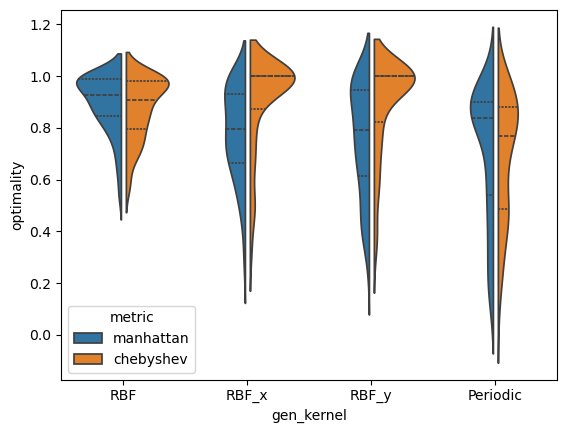

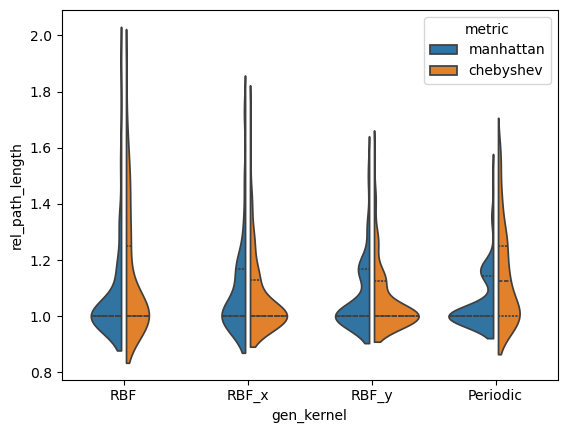

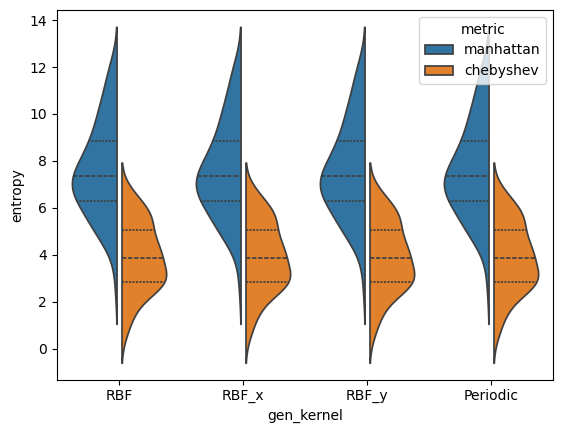

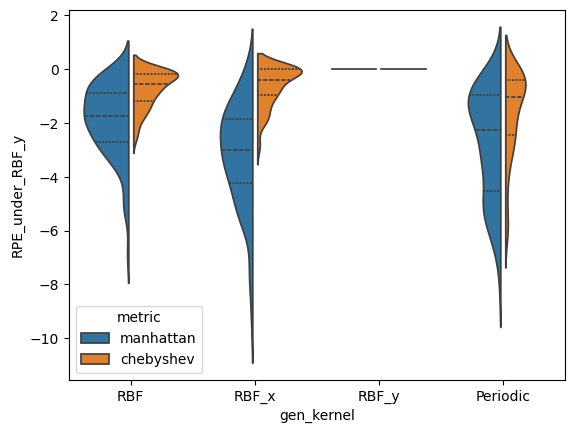

In [22]:
## differences in structure-conferred optimal paths

## path lengths, relative to the simple path - i.e. how much longer is each kernel's optimal path compared to the simple path?
df_gp['rel_path_length'] = df_gp['n_optimal']/df_gp['n_simple']

## jaccard similarity between different optimal paths
for k in kernel_names:
    df_gp['vs '+k] = np.zeros(len(df_gp))
df_gp['mean jacc'] = np.zeros(len(df_gp))
df_gp['global_jacc'] = np.zeros(len(df_gp))
df_gp['entropy'] = np.zeros(len(df_gp))
df_gp['patch entropy'] = np.zeros(len(df_gp))

## loop through trials
for t in range(n_trials):
    jaccs = []

    ## loop through metrics
    for m in metrics:

        ## loop through kernels
        for k1 in kernel_names:
            path_1 = df_gp.loc[(df_gp['gen_kernel']==k1) & (df_gp['trial']==t) & (df_gp['metric']==m), 'o_traj'].values[0]

            ## calculate the jaccard similarity of paths with each other kernel-conferred path
            for k2 in kernel_names:
                if k1 == k2:
                    jaccs.append(np.nan)
                else:
                    path_2 = df_gp.loc[(df_gp['gen_kernel']==k2) & (df_gp['trial']==t)  & (df_gp['metric']==m), 'o_traj'].values[0]
                    jaccs.append(gp.jaccard(path_1, path_2))
                df_gp.loc[(df_gp['gen_kernel']==k1) & (df_gp['trial']==t)  & (df_gp['metric']==m), 'vs '+k2] = jaccs[-1]

        ## average
        df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'mean jacc'] = np.nanmean(jaccs)

        ## or, calculate the global jaccarrd similarity of all paths on that trial
        all_paths = df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'o_traj'].values
        df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'global_jacc'] = gp.global_jaccard(all_paths)

        ## equivalently, calculate the entropy-based diversity of the paths
        df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'entropy'] = gp.entropy(all_paths)
        df_gp.loc[(df_gp['trial']==t)  & (df_gp['metric']==m), 'patch entropy'] = gp.patch_entropy(all_paths)


## plots
plt.figure()
sns.violinplot(data = df_gp, x = 'gen_kernel', y = 'optimality', hue = 'metric', split = True, inner = 'quartile', gap = 0.1)
plt.figure()
sns.violinplot(data = df_gp, x = 'gen_kernel', y = 'rel_path_length', hue = 'metric', split = True, inner = 'quartile', gap = 0.1)
plt.figure()
sns.violinplot(data = df_gp, x = 'gen_kernel', y = 'entropy', hue = 'metric', split = True, inner = 'quartile', gap = 0.1)
plt.figure()
sns.violinplot(data = df_gp, x = 'gen_kernel', y = 'RPE_under_RBF_y', hue = 'metric', split = True, inner = 'quartile', gap = 0.1)

## Agent makes observations

  0%|          | 0/100 [00:00<?, ?it/s]

/var/folders/6f/wv4903p948xgctshsywsz13r0000gq/T/ipykernel_25672/3222897143.py:103: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_agent = pd.concat([df_agent, df_tmp], ignore_index = True)


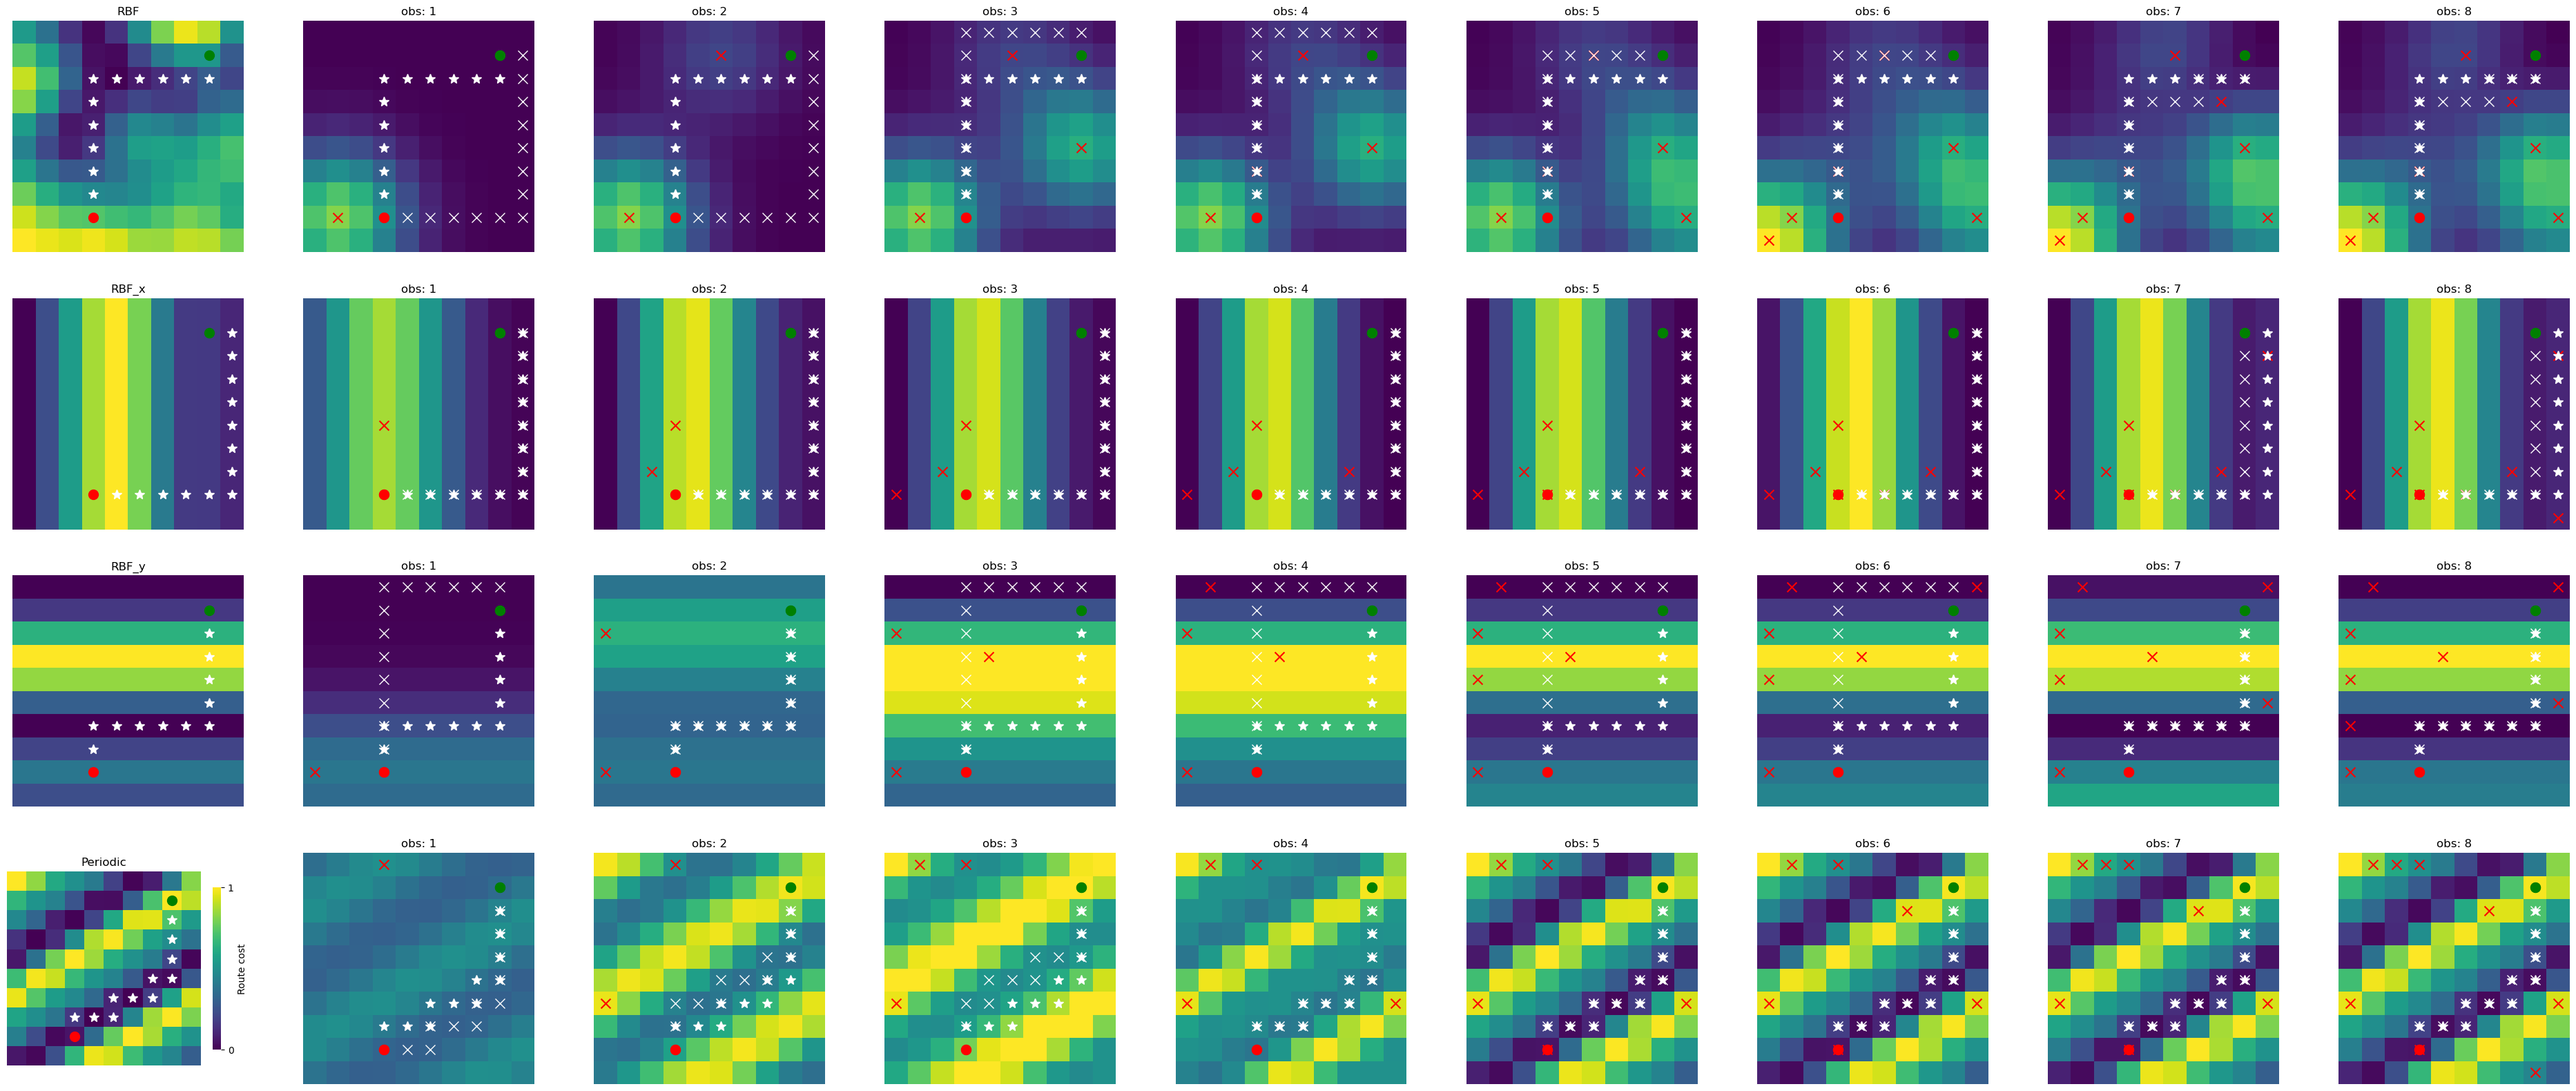

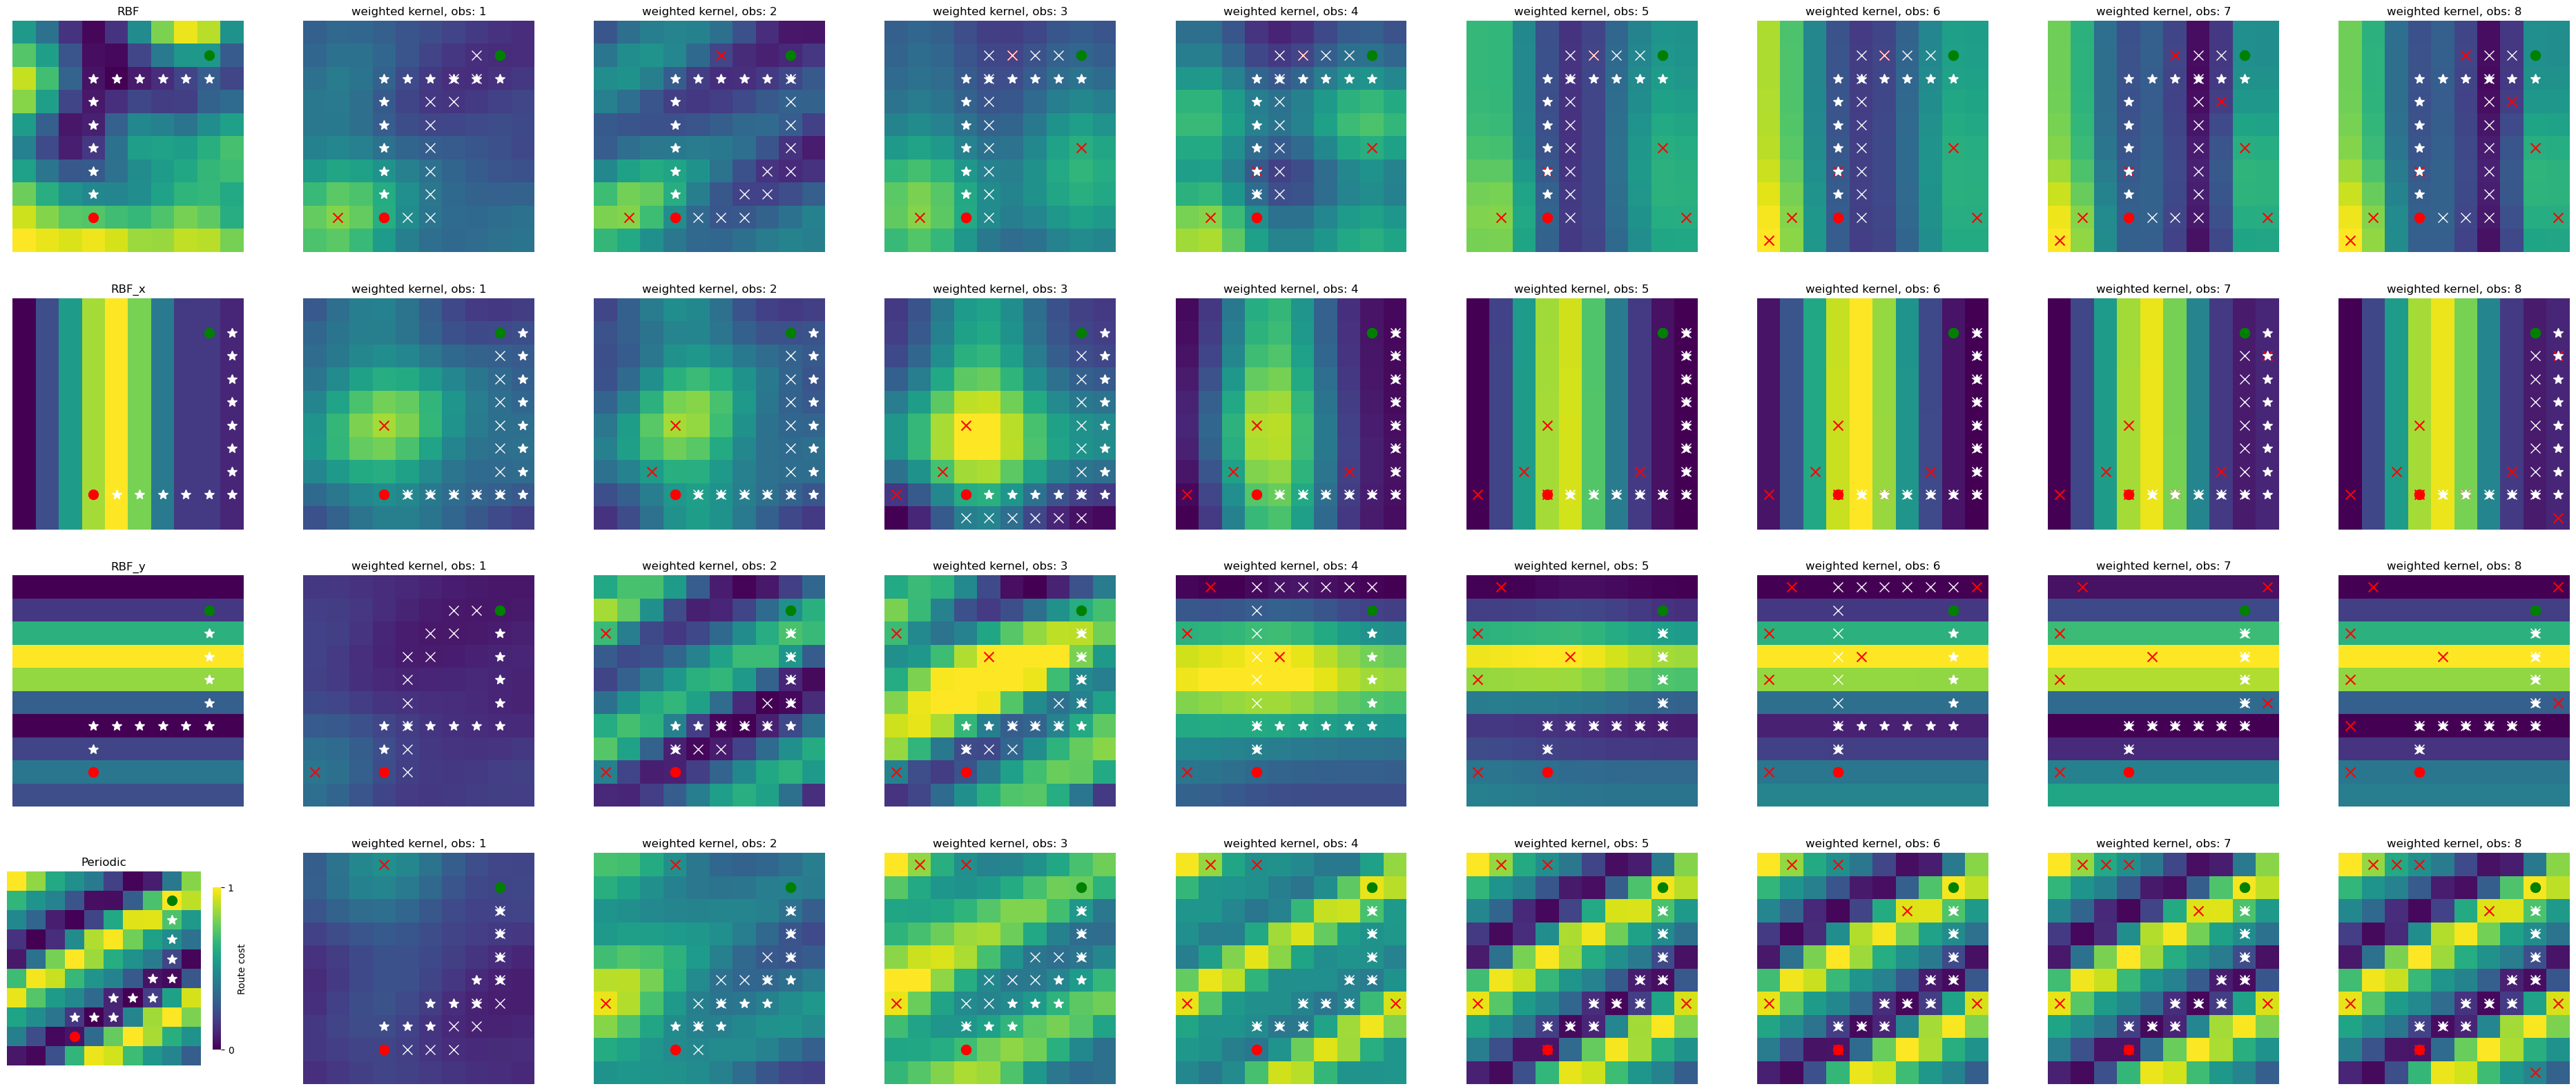

In [24]:
importlib.reload(plotter)
from plotter import *
"""
- Agent makes point observations from the true reward distribution
- After each observation, the agent calculates the posterior over the entire environment under each of the kernels, and then takes the optimal path under each of the kernels
- Alternatively, the observations are made along the route.
- The question is therefore whether we want exploration to be on-route, or route-independent
"""

## init info
n_obs = 8
columns = [
    'trial',
    'n_obs',
    'metric',
    'gen_kernel',
    'inf_kernel',
    'optimal_cost',
    'n_optimal',
    'actual_cost',
    'n_actual',
    'RPE'
]
df_agent = pd.DataFrame(columns = columns)
n_plotting_ts = 1
plotting_ts = np.random.randint(0,n_trials,n_plotting_ts)
# plotting_ts = [1]

plotting_metric = 'manhattan'

## for each trial
for t in tqdm(range(n_trials)):
# for t in tqdm(range(5)):
    pair = all_pairs[t]
    if t in plotting_ts:
        fig, axs = plt.subplots(n_k,n_obs+1, figsize=(n_obs*6,n_k*5))
        fig2, axs2 = plt.subplots(n_k,n_obs+1, figsize=(n_obs*6,n_k*5))

    ## for each generative kernel (i.e. true reward distribution)
    for kg, k_gen in enumerate(koi):
        k_gen_name = kernel_names[kg]
        true_samples = all_samples[k_gen_name][t]

        ## observations from true reward distribution
        all_obs = gp.gen_obs(true_samples, n_obs)

        ## plot true reward distribution and ground truth optimal path
        if t in plotting_ts:
            plot_r(true_samples, axs[kg,0], k_gen_name, cbar = kg==(len(koi)-1))
            optimal_traj = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['trial']==t) & (df_gp['metric']==plotting_metric), 'o_traj'].values[0]
            plot_traj([optimal_traj], axs[kg,0])

            plot_r(true_samples, axs2[kg,0], k_gen_name, cbar = kg==(len(koi)-1))
            optimal_traj = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['trial']==t) & (df_gp['metric']==plotting_metric), 'o_traj'].values[0]
            plot_traj([optimal_traj], axs2[kg,0])


        ## for each inference kernel
        for ki, k_inf in enumerate(koi):
            k_inf_name = kernel_names[ki]

            ## incrementally increase the number of observations
            for o in range(n_obs):
                obs = all_obs[:o+1]

                ## calculate posterior over the entire environment, given the observations made so far
                post_mean, post_cov = gp.post_pred(k_inf, obs)

                ## (UCB, i.e. give states with high posterior covariance, and therefore uncertain paths, extra weight?)
                # beta = 0.8
                # post_mean -= beta*np.sqrt(np.diag(post_cov)) #subtract, because the pathfinder is minimising cost

                if post_mean.min()<0: ## to ensure the posterior is non-negative
                    post_mean -= post_mean.min()

                ## agent takes route based on this posterior
                for metric in metrics:
                    actual_traj, _ = gp.optimal_trajectory(pair,post_mean.reshape(N,N),metric,0)
                    n_actual = len(o_traj)
                    actual_route_cost = [true_samples[x, y] for x, y in actual_traj]
                    actual_cost = np.sum(actual_route_cost)

                    ## calculate RPE
                    optimal_cost = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['trial']==t) & (df_gp['metric']==metric), 'optimal_cost'].values[0]
                    # RPE = optimal_cost - actual_cost
                    RPE = actual_cost/optimal_cost 

                    row = pd.Series({
                        'trial': t,
                        'n_obs': o+1,
                        'metric': metric,
                        'gen_kernel': k_gen_name,
                        'inf_kernel': k_inf_name,
                        'optimal_cost': optimal_cost,
                        'n_optimal': n_optimal,
                        'actual_cost': actual_cost,
                        'n_actual': n_actual,
                        'RPE': RPE
                    })
                    df_tmp = pd.DataFrame(columns = columns)
                    for key in row.keys():
                        df_tmp[key] = [row[key]]
                    df_agent = pd.concat([df_agent, df_tmp], ignore_index = True)


                    ## after each observation, plot the posterior under the correct kernel, and its optimal path
                    if t in plotting_ts:
                        if metric == plotting_metric:
                            if k_inf_name == k_gen_name:
                                # title = k_gen_name#+'\n'+str(np.round(100*RPE/optimal_cost))+'%'
                                title = 'obs: '+str(o+1)
                                plot_r(post_mean.reshape(N,N), axs[kg,o+1], title, cbar = False)
                                plot_obs(obs, axs[kg,o+1], text=False)
                                plot_traj([optimal_traj,actual_traj], axs[kg,o+1])



        ### or, the agent makes observations and uses the marginal likelihoods of the inference kernels to make a weighted decision about which kernel to use

        ## incrementally increase the number of observations
        for o in range(n_obs):
            obs = all_obs[:o+1]
            lls = []
            post_means = []

            ## for each inference kernel
            for ki, k_inf in enumerate(koi):
                k_inf_name = kernel_names[ki]

                ## posterior over the entire environment, given the observations made so far
                post_mean, post_cov = gp.post_pred(k_inf, obs)
                # if post_mean.min()<0:
                #     post_mean -= post_mean
                post_means.append(post_mean)
            
                ## calculate the likelihood of the observations under this kernel
                ll = gp.likelihood(k_inf, obs)
                lls.append(ll)

            ## free params per kernel type? 
            # n_params = np.array([2, 3, 3, 4])
            # prior = penalised_uniform(n_params)
            # lls = lls*prior
            
            ## weight each posterior mean by the corresponding kernel's marginal likelihood
            k_weights = softmax(lls)
            weighted_post_mean = np.sum([k_weights[i]*post_means[i] for i in range(len(koi))], axis = 0)
            if weighted_post_mean.min()<0:
                weighted_post_mean -= weighted_post_mean.min()

            ## agent takes route based on this weighted posterior
            for metric in metrics:
                actual_traj, _ = gp.optimal_trajectory(pair,weighted_post_mean.reshape(N,N),metric,0)
                n_actual = len(o_traj)
                actual_route_cost = [true_samples[x, y] for x, y in actual_traj]
                actual_cost = np.sum(actual_route_cost)

                ## calculate RPE
                optimal_cost = df_gp.loc[(df_gp['gen_kernel']==k_gen_name) & (df_gp['trial']==t) & (df_gp['metric']==metric), 'optimal_cost'].values[0]
                # RPE = optimal_cost - actual_cost
                RPE = actual_cost/optimal_cost 

                row = pd.Series({
                    'trial': t,
                    'n_obs': o+1,
                    'metric': metric,
                    'gen_kernel': k_gen_name,
                    'inf_kernel': 'weighted',
                    'optimal_cost': optimal_cost,
                    'n_optimal': n_optimal,
                    'actual_cost': actual_cost,
                    'n_actual': n_actual,
                    'RPE': RPE
                })
                ## save weight for each kernel
                for ki, k_inf in enumerate(koi):
                    k_inf_name = kernel_names[ki]
                    row['weight_'+k_inf_name] = k_weights[ki]
                df_tmp = pd.DataFrame(columns = columns)
                for key in row.keys():
                    df_tmp[key] = [row[key]]
                df_agent = pd.concat([df_agent, df_tmp], ignore_index = True)

                ## after each observation, plot the weighted posterior, and its optimal path
                if t in plotting_ts:
                    if metric == plotting_metric:
                        title = 'weighted kernel, obs: '+str(o+1)
                        plot_r(weighted_post_mean.reshape(N,N), axs2[kg,o+1], title, cbar = False)
                        plot_obs(obs, axs2[kg,o+1], text=False)
                        plot_traj([optimal_traj,actual_traj], axs2[kg,o+1])



        ## plot
        # if t in plotting_ts:
        #     for mi, metric in enumerate(['chebyshev']):
        #         title = k_gen_name
        #         plot_r(true_samples, axs[0,kg], title, cbar = kg==(len(koi)-1))
        #         plot_obs(all_obs, axs[0,kg], text=False)
        #         for ki, k_inf in enumerate(koi):
        #             k_inf_name = kernel_names[ki]
        #             post_mean, post_cov = gp.post_pred(k_inf, all_obs)
        #             title = k_inf_name
        #             plot_r(post_mean.reshape(N,N), axs[mi+1,kg], title, cbar = kg==(len(koi)-1))
        #             textstr = '\n'.join((
        #                 f'Optimal: n={n_optimal}, {np.round(optimal_cost, 3)}',
        #                 f'Actual: n={n_actual}, {np.round(actual_cost, 3)}',
        #                 f'RPE: {np.round(RPE, 3)}'))
        #             props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        #             axs[mi+1,kg].text(0.0, -0.05, textstr, transform=axs[mi+1,kg].transAxes, fontsize=14,
        #                         verticalalignment='top', bbox=props)






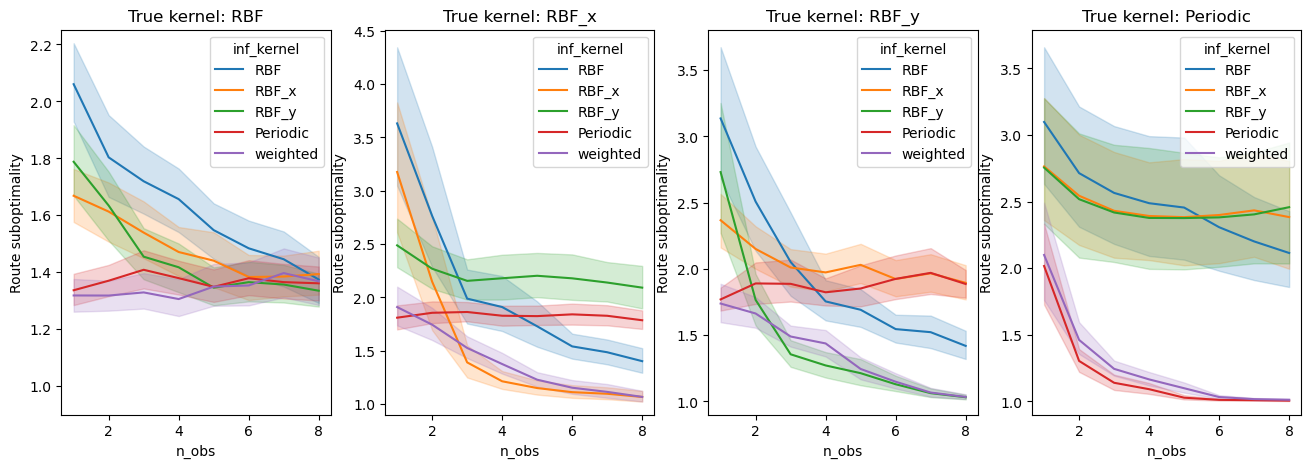

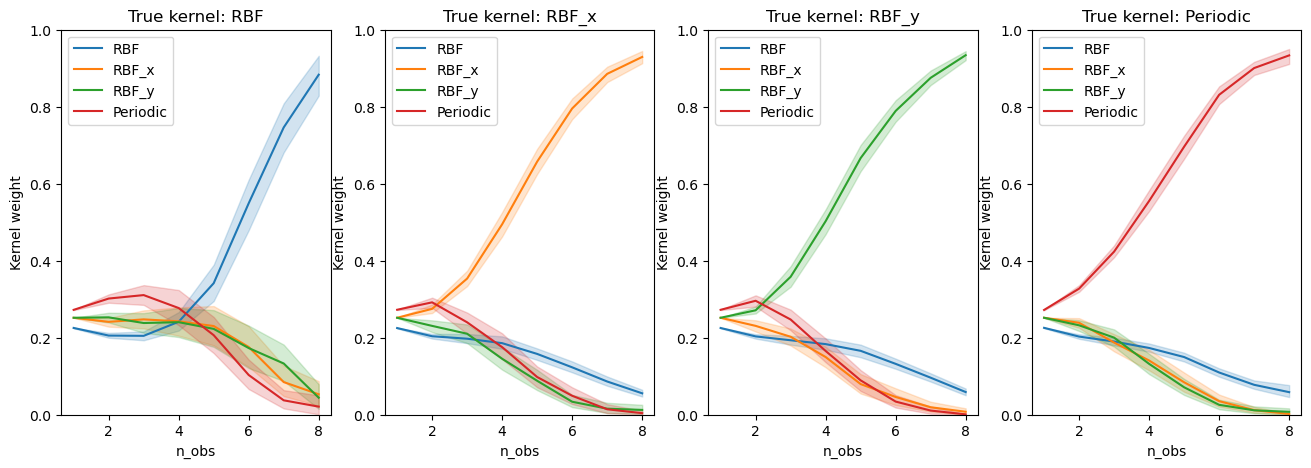

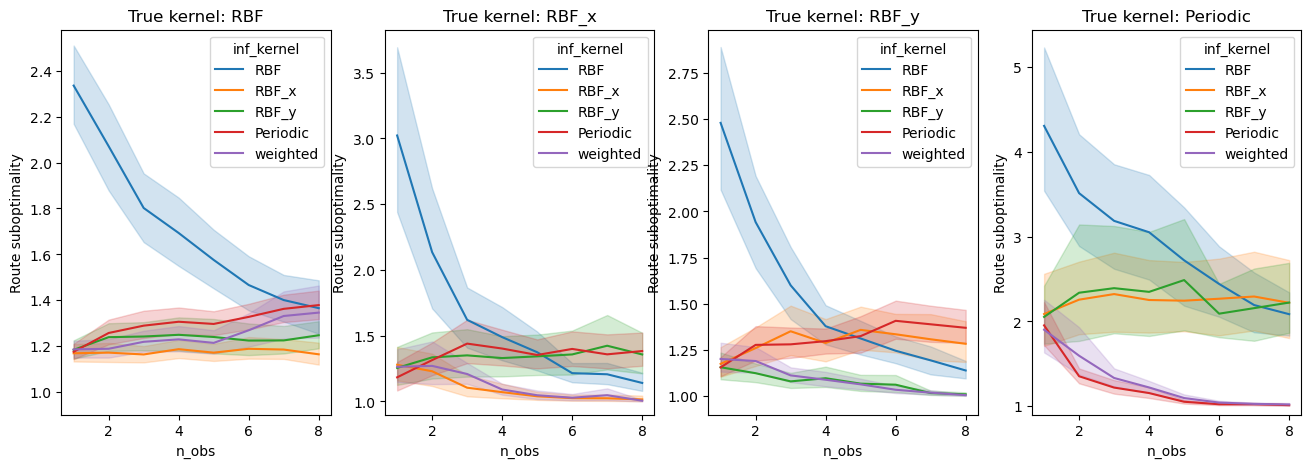

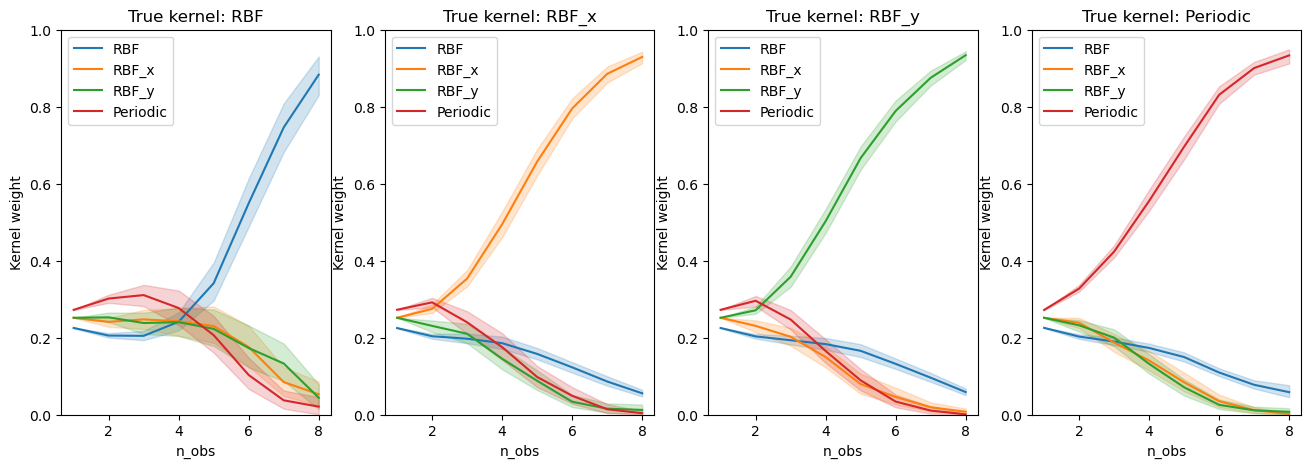

In [111]:
for metric in metrics:
    fig, axs = plt.subplots(1, n_k, figsize=(4*n_k, 5))
    fig2, axs2 = plt.subplots(1, n_k, figsize=(4*n_k, 5))

    for gki, gen_k in enumerate(df_agent['gen_kernel'].unique()):
        data_tmp = df_agent.loc[(df_agent['gen_kernel']==gen_k) & (df_agent['metric']==metric)]
        sns.lineplot(data = data_tmp, x = 'n_obs', y = 'RPE', hue = 'inf_kernel', ax = axs[gki], markers = True)
        axs[gki].set_title('True kernel: '+gen_k)
        axs[gki].set_ylabel('Route suboptimality')
        axs[gki].set_ylim(0.9,)
        ## suptitle
        # plt.suptitle('Metric: '+metric)

        ## plot the weights of each inference kernel
        for iki, inf_k in enumerate(df_agent['gen_kernel'].unique()):
            sns.lineplot(data = data_tmp.loc[data_tmp['inf_kernel']=='weighted'], x = 'n_obs', y = 'weight_'+inf_k, ax = axs2[gki], markers = True, label = inf_k)
            axs2[gki].set_title('True kernel: '+gen_k)
            axs2[gki].set_ylabel('Kernel weight')
            axs2[gki].set_ylim(0,1)
        # sns.lineplot(data = data_tmp, x = 'n_obs', y = '', hue = 'inf_kernel', ax = axs2[gki], markers = True)

ValueError: not enough values to unpack (expected 4, got 2)

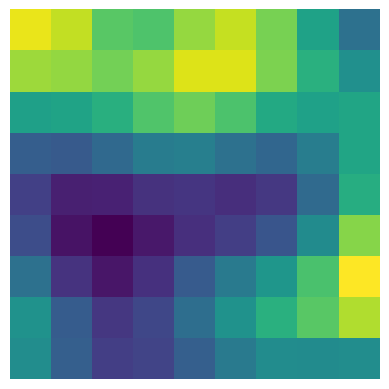

In [21]:
## sample from a GP using an RBF kernel
gp = GP_world(9, params)
samples = gp.sample(gp.K_rbf)
axs = plt.subplot()
plot_r(samples,axs)

## imagine that P has made 3 observations from the left middle of the environment
axs = plt.subplot()
plot_r(samples,axs)
obs = np.array([[4,4],[4,5],[4,6]])
plot_obs(obs, axs)

## BAMCP 

In [7]:
import uuid
uuid.uuid1()

UUID('09c93b1c-8acd-11ef-886e-6a741f1f7f9c')

In [8]:
## funcs for visualising MCTS
def vertical_lines(last_node_flags):
    vertical_lines = []
    vertical_line = '\u2502'
    for last_node_flag in last_node_flags[0:-1]:
        if last_node_flag == False:
            vertical_lines.append(vertical_line + ' ' * 3)
        else:
            # space between vertical lines
            vertical_lines.append(' ' * 4)
    return ''.join(vertical_lines)

def horizontal_line(last_node_flags):
    horizontal_line = '\u251c\u2500\u2500 '
    horizontal_line_end = '\u2514\u2500\u2500 '
    if last_node_flags[-1]:
        return horizontal_line_end
    else:
        return horizontal_line
    

## node class
class Node:
    def __init__(self, state, action, action_space, reward, terminal):
        self.identifier = str(uuid.uuid1())
        self.parent_identifier = None
        self.children_identifiers = []
        self.untried_actions = list(range(action_space))
        self.state = state
        self.total_sim_reward = 0
        self.n_visits = 0
        self.performance = 0
        self.action = action
        self.reward = reward
        self.terminal = terminal

    
    def __str__(self):
        return "{}: (action={}, visits={}, reward={:d}, ratio={:0.4f})".format(
                                                  self.state,
                                                  self.action,
                                                  self.num_visits,
                                                  int(self.total_simulation_reward),
                                                  self.performance)

    def untried_action(self):
        action = np.random.choice(self.untried_actions)
        self.untried_actions.remove(action)
        return action

## tree class
class Tree:

    def __init__(self):
        self.nodes = {}
        self.root = None

    ## check if node is expandable
    def is_expandable(self, node):
        if node.terminal:
            return False
        if len(node.untried_actions) > 0:
            return True
        return False

    ## traverse the tree to yield edges and nodes
    def iter(self, identifier, depth, last_node_flags):
        if identifier is None:
            node = self.root
        else:
            node = self.nodes[identifier]

        if depth == 0:
            yield "", node
        else:
            yield vertical_lines(last_node_flags) + horizontal_line(last_node_flags), node

        children = [self.nodes[identifier] for identifier in node.children_identifiers]
        last_index = len(children) - 1

        depth += 1
        for index, child in enumerate(children):
            last_node_flags.append(index == last_index)
            for edge, node in self.iter(child.identifier, depth, last_node_flags):
                yield edge, node
            last_node_flags.pop()

    def add_node(self, node, parent=None):
        self.nodes.update({node.identifier: node})

        if parent is None:
            self.root = node
            self.nodes[node.identifier].parent = None
        else:
            self.nodes[parent.identifier].children_identifiers.append(node.identifier)
            self.nodes[node.identifier].parent_identifier=parent.identifier

    def children(self, node):
        children = []
        for identifier in self.nodes[node.identifier].children_identifiers:
            children.append(self.nodes[identifier])
        return children

    def parent(self, node):
        parent_identifier = self.nodes[node.identifier].parent_identifier
        if parent_identifier is None:
            return None
        else:
            return self.nodes[parent_identifier]

    def show(self):
        lines = ""
        for edge, node in self.iter(identifier=None, depth=0, last_node_flags=[]):
            lines += "{}{}\n".format(edge, node)
        print(lines)

In [9]:
import random
from math import sqrt, log
# from utilities.node import Node

class MonteCarloTreeSearch():

    def __init__(self, env, tree):
        self.env = env
        self.tree = tree
        self.action_space = self.env.action_space.n
        state = self.env.reset()
        self.tree.add_node(Node(state=state, action=None, action_space=self.action_space, reward=0, terminal=False))

    def expand(self, node):
        action = node.untried_action()
        state, reward, done, _ = self.env.step(action)
        new_node = Node(state=state, action=action, action_space=self.action_space, reward=reward, terminal=done)
        self.tree.add_node(new_node, node)
        return new_node

    def default_policy(self, node):
        if node.terminal:
            return node.reward

        while True:
            action = random.randint(0, self.action_space-1)
            state, reward, done, _ = self.env.step(action)
            if done:
                return reward

    def compute_value(self, parent, child, exploration_constant):
        exploitation_term = child.total_simulation_reward / child.num_visits
        exploration_term = exploration_constant * sqrt(2 * log(parent.num_visits) / child.num_visits)
        return exploitation_term + exploration_term

    def best_child(self, node, exploration_constant):
        best_child = self.tree.children(node)[0]
        best_value = self.compute_value(node, best_child, exploration_constant)
        iter_children = iter(self.tree.children(node))
        next(iter_children)
        for child in iter_children:
            value = self.compute_value(node, child, exploration_constant)
            if value > best_value:
                best_child = child
                best_value = value
        return best_child

    def tree_policy(self):
        node = self.tree.root
        while not node.terminal:
            if self.tree.is_expandable(node):
                return self.expand(node)
            else:
                node = self.best_child(node, exploration_constant=1.0/sqrt(2.0))
                state, reward, done, _ = self.env.step(node.action)
                assert node.state == state
        return node

    def backward(self, node, value):
        while node:
            node.num_visits += 1
            node.total_simulation_reward += value
            node.performance = node.total_simulation_reward/node.num_visits
            node = self.tree.parent(node)

    def forward(self):
        self._forward(self.tree.root)

    def _forward(self,node):
        best_child = self.best_child(node, exploration_constant=0)

        print("****** {} ******".format(best_child.state))

        for child in self.tree.children(best_child):
            print("{}: {:0.4f}".format(child.state, child.performance))

        if len(self.tree.children(best_child)) > 0:
            self._forward(best_child)

## Gym sesh

In [16]:
from typing import Optional
import pygame

## define 2D env
class Mountain_Env(gym.Env):
    metadata = {"render.modes": ["human", "rgb_array"], "render_fps": 4}

    def __init__(self, size: int = 5, render_mode=None):
        
        # The size of the square grid and window
        self.size = size
        self.window_size = 100

        # Define the agent and target location; randomly chosen in `reset` and updated in `step`
        self._agent_location = np.array([-1, -1], dtype=np.int32)
        self._target_location = np.array([-1, -1], dtype=np.int32)

        # Observations are dictionaries with the agent's and the target's location.
        # Each location is encoded as an element of {0, ..., `size`-1}^2
        self.observation_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),
                "target": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),
            }
        )

        # We have 4 actions, corresponding to "right", "up", "left", "down"
        self.action_space = gym.spaces.Discrete(4)

        # Dictionary maps the abstract actions to the directions on the grid
        self._action_to_direction = {
            0: np.array([1, 0]),  # right
            1: np.array([0, 1]),  # up
            2: np.array([-1, 0]),  # left
            3: np.array([0, -1]),  # down
        }

        ## render the env
        assert render_mode is None or render_mode in self.metadata["render.modes"]
        self.render_mode = render_mode
        self.window = None
        self.clock = None


    ## construct obss
    def _get_obs(self):
        return {"agent": self._agent_location, "target": self._target_location}
    
    ## manhattan distance from target
    def _get_info(self):
        return {
            "distance": np.linalg.norm(
                self._agent_location - self._target_location, ord=1
            )
        }
    
    ## initiate new episode for the env
    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        # We need the following line to seed self.np_random
        super().reset(seed=seed)

        # Choose the agent's location uniformly at random
        self._agent_location = self.np_random.integers(0, self.size, size=2, dtype=int)

        # We will sample the target's location randomly until it does not coincide with the agent's location
        self._target_location = self._agent_location
        while np.array_equal(self._target_location, self._agent_location):
            self._target_location = self.np_random.integers(
                0, self.size, size=2, dtype=int
            )

        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == 'human':
            self._render_frame()

        return observation, info
    
    ## step function
    def step(self, action):
        
        # Map the action (element of {0,1,2,3}) to the direction we walk in
        direction = self._action_to_direction[action]

        # We use `np.clip` to make sure we don't leave the grid bounds
        self._agent_location = np.clip(
            self._agent_location + direction, 0, self.size - 1
        )

        # An environment is completed if and only if the agent has reached the target (OR IF THE AGENT RUNS OUT OF ENERGY?)
        terminated = np.array_equal(self._agent_location, self._target_location)
        truncated = False
        reward = 1 if terminated else 0  # the agent is only reached at the end of the episode
        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == 'human':
            self._render_frame()

        return observation, reward, terminated, truncated, info
    
    ## render the env
    def render(self):
        if self.render_mode == "rgb_array":
            return self._render_frame()

    def _render_frame(self):
        if self.window is None and self.render_mode == "human":
            pygame.init()
            pygame.display.init()
            self.window = pygame.display.set_mode(
                (self.window_size, self.window_size)
            )
        if self.clock is None and self.render_mode == "human":
            self.clock = pygame.time.Clock()

        canvas = pygame.Surface((self.window_size, self.window_size))
        canvas.fill((255, 255, 255))
        pix_square_size = (
            self.window_size / self.size
        )  # The size of a single grid square in pixels

        # First we draw the target
        pygame.draw.rect(
            canvas,
            (255, 0, 0),
            pygame.Rect(
                pix_square_size * self._target_location,
                (pix_square_size, pix_square_size),
            ),
        )
        # Now we draw the agent
        pygame.draw.circle(
            canvas,
            (0, 0, 255),
            (self._agent_location + 0.5) * pix_square_size,
            pix_square_size / 3,
        )

        # Finally, add some gridlines
        for x in range(self.size + 1):
            pygame.draw.line(
                canvas,
                0,
                (0, pix_square_size * x),
                (self.window_size, pix_square_size * x),
                width=3,
            )
            pygame.draw.line(
                canvas,
                0,
                (pix_square_size * x, 0),
                (pix_square_size * x, self.window_size),
                width=3,
            )

        if self.render_mode == "human":
            # The following line copies our drawings from `canvas` to the visible window
            self.window.blit(canvas, canvas.get_rect())
            pygame.event.pump()
            pygame.display.update()

            # We need to ensure that human-rendering occurs at the predefined framerate.
            # The following line will automatically add a delay to keep the framerate stable.
            self.clock.tick(self.metadata["render_fps"])
        else:  # rgb_array
            return np.transpose(
                np.array(pygame.surfarray.pixels3d(canvas)), axes=(1, 0, 2)
            )
        
    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()

In [37]:
## register env
# register(
#     id="mountains/MountainEnv-v0",
#     entry_point='mountains.envs:MountainEnv',
#     max_episode_steps=100,
#     kwargs={"size": 10},
# )

# !pip install -e .


## create env
import mountains
env = gym.make("mountains/MountainEnv-v0", size=4, render_mode='human')

observation, info = env.reset()

for _ in range(100):
    action = env.action_space.sample()  # random action
    observation, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        observation, info = env.reset()

env.close()

In [11]:
import gymnasium as gym

base_env = gym.make('FrozenLake-v1', render_mode="human", is_slippery=False)

observation, info = env.reset()

# for _ in range(100):
#     action = env.action_space.sample()  # random action
#     observation, reward, terminated, truncated, info = env.step(action)

#     if terminated or truncated:
#         observation, info = env.reset()

# env.close()